# Clase 1 – Actividad Práctica Integrada
## Introducción al Aprendizaje Automático

En esta actividad exploraremos un dataset simple, identificaremos el tipo de aprendizaje adecuado, entrenaremos nuestro primer modelo con scikit‑learn y resolveremos dos desafíos gamificados.

## Formalización matemática del aprendizaje supervisado

En un problema de **aprendizaje supervisado**, contamos con un conjunto de datos:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n
$$

donde:

-  $$ x_i \in \mathbb{R}^d $$ es un vector de atributos,
-  $$ y_i $$ es la etiqueta o variable objetivo.

El objetivo del modelo es aprender una función:

$$
f_\theta : \mathbb{R}^d \rightarrow \mathcal{Y}
$$

parametrizada por $ \theta $, tal que minimice el error entre las predicciones y los valores reales:

$$
\theta^* = \arg\min_\theta \frac{1}{n} \sum_{i=1}^n L(f_\theta(x_i), y_i)
$$

donde $ L $ es una función de pérdida (por ejemplo, entropía cruzada o error cuadrático).


## Regresión Logística: formalización matemática

La regresión logística modela la probabilidad de pertenecer a una clase:

$$
P(y=1 \mid x) = \sigma(w^\top x + b)
$$

donde:

- $ w $ es el vector de pesos,
- $ b $ es el sesgo,
- $ \sigma(z) = \frac{1}{1 + e^{-z}} $ es la función sigmoide.

El entrenamiento consiste en minimizar la pérdida logística:

$$
L(w, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

donde \( \hat{y}_i = \sigma(w^\top x_i + b) \).


##  Métrica: Accuracy

La métrica **accuracy** mide la proporción de predicciones correctas:

$$
\text{Accuracy} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(\hat{y}_i = y_i)
$$

donde $ \mathbf{1}(\cdot) $ es la función indicadora.


##  Flujo matemático del entrenamiento de un modelo

El proceso general de entrenamiento puede expresarse como:

1. Inicializar parámetros $ \theta $.
2. Calcular predicciones $ \hat{y}_i = f_\theta(x_i) $.
3. Calcular la pérdida total:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n L(\hat{y}_i, y_i)
$$

4. Actualizar parámetros mediante descenso de gradiente:

$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta)
$$

donde $ \eta $ es la tasa de aprendizaje.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
data = load_iris()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Pregunta 1
El dataset Iris contiene ejemplos etiquetados (clases 0, 1 y 2).  
**¿Este problema corresponde a aprendizaje supervisado o no supervisado? Explica por qué.**

**Respuesta:** Es aprendizaje supervisado porque el dataset contiene categorias etiquetadas,significa que durante el proceso de entrenamiento al modelo se le entregan tanto las características de los datos (X_train) como las categorías a las que pertenecen (y_train) para que aprenda a identificarlas.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
accuracy

1.0

### Pregunta 2
El modelo entrenado obtuvo un accuracy de aproximadamente **X** (valor mostrado arriba).

- ¿Qué significa este valor en términos prácticos?
- ¿Qué factores podrían mejorar o empeorar este resultado?

**Respuesta 1:** Significa que el modelo tuvo un 100% de aciertos.


**Respuesta 2:**


*   Para empeorarlo prodriamos entrenar el modelo con datos incorrectos o con "ruido" (medidas mal anotadas), reducir mucho la cantidad de datos de entrenamiento, o el sobreajuste .
*   Y para mejorarlo podríamos entrenarlo con un volumen de datos mucho más masivo y diverso, o usar técnicas como validación cruzada para asegurar que ese 100% no fue solo suerte al momento de dividir los datos.





In [5]:
sample = X_test[:5]
true_labels = y_test[:5]
predictions = model.predict(sample)

pd.DataFrame({
    'Real': true_labels,
    'Predicción': predictions
})

,Real,Predicción
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1


## 🔍 Desafío 1 — El Detective del Dataset

Tu misión es descubrir **qué clase del dataset Iris** es más fácil de separar usando solo **dos atributos**.

### Pasos:
1. Elegí dos columnas del dataset (por ejemplo: `sepal length` y `petal width`).
2. Graficá un scatter plot coloreado por clase.
3. Observá visualmente qué clases parecen más separables.
4. Explicá tu razonamiento en 3–5 líneas.

### Bonus:
- Probá con otras combinaciones de atributos.
- ¿Cuál combinación te dio la mejor separación visual?

3. La clase representada por los puntos morados (que corresponde a la etiqueta 0).

4. Como se observa en el diagrama de dispersión, los puntos morados forman un clúster denso y completamente aislado en la parte superior izquierda. Por el contrario, los puntos verdes y amarillos (clases 1 y 2) están fuertemente superpuestos en el centro y la derecha del gráfico. Esto indica que, usando solo las dimensiones del sépalo, es muy fácil identificar a la primera especie, pero resulta casi imposible separar visualmente a las otras dos.


### Bonus:
-¿Con cuáles otras combinaciones probar?
dejar de lado los sépalos (sepal length y sepal width) y pasar a evaluar las dimensiones de los pétalos: petal length y petal width .

-¿Cuál combinación te dio la mejor separación visual?

La mejor combinación absoluta para este dataset es Petal Length vs Petal Width (Longitud del pétalo vs Ancho del pétalo).

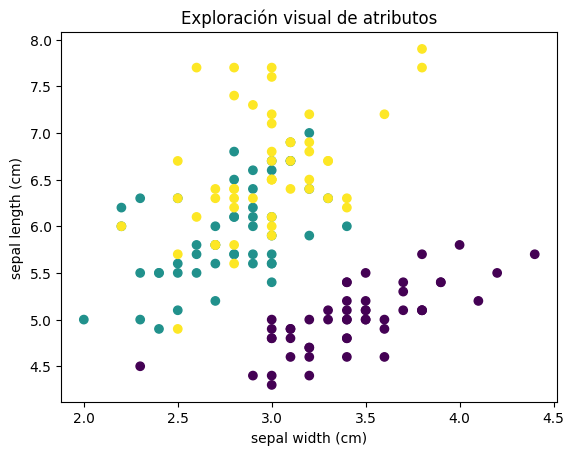

In [10]:
# Invertimos los datos: columna 1 (width) en X, y columna 0 (length) en Y
plt.scatter(df.iloc[:,1], df.iloc[:,0], c=df['target'])

# Mantenemos las etiquetas invertidas para que coincidan
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[0])
plt.title('Exploración visual de atributos')
plt.show()

## 🧠 Desafío 2 — Vence al Modelo

Tu objetivo es **superar el accuracy obtenido por el modelo base** entrenado en esta actividad.

### Reglas:
- Podés modificar SOLO uno de estos elementos:
  - el tamaño del conjunto de prueba,
  - el modelo (cambiar LogisticRegression por otro simple),
  - o los atributos utilizados (seleccionar solo algunos).

### Pasos:
1. Elegí qué vas a modificar.
2. Entrená nuevamente el modelo.
3. Compará tu accuracy con el original.
4. Explicá por qué creés que tu cambio mejoró o empeoró el rendimiento.

### Bonus:
- Si lográs superar el accuracy por más de 5%, ganás el **Logro: Ajustador de Modelos**.

**Respuesta:** Aunque el accuracy se mantuvo en 1.0 (ya que es el tope máximo matemático y el modelo base ya lo había alcanzado), el rendimiento real del modelo mejoró en términos de eficiencia. Al eliminar los datos de los sépalos (que según el análisis visual generaban ruido y superposición entre las clases Versicolor y Virginica) y entrenar al algoritmo exclusivamente con los pétalos, logramos el mismo 100% de precisión pero procesando la mitad de la información. Esto hace que el modelo sea más rápido, más ligero y menos propenso al sobreajuste (overfitting).

In [11]:

X_petalos = X[:, 2:4]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_petalos, y, test_size=0.2, random_state=42)

modelo_optimizado = LogisticRegression(max_iter=1000)
modelo_optimizado.fit(X_train_p, y_train_p)

nuevo_accuracy = modelo_optimizado.score(X_test_p, y_test_p)

print(f"Accuracy original: 1.0") # El que obtuve antes
print(f"Nuevo Accuracy (solo pétalos): {nuevo_accuracy}")

Accuracy original: 1.0
Nuevo Accuracy (solo pétalos): 1.0


# 📊 Rúbrica de Evaluación – Actividad Práctica Clase 1

| Criterio | Excelente (5) | Bueno (4) | Aceptable (3) | Insuficiente (1–2) |
|---------|---------------|-----------|---------------|---------------------|
| **Comprensión conceptual** | Explica claramente supervisado/no supervisado y el flujo de ML con ejemplos propios. | Explica correctamente pero sin ejemplos propios. | Explica parcialmente o con confusiones menores. | Explicación incompleta o incorrecta. |
| **Correcta ejecución del código** | Todo el código funciona, está ordenado y comentado. | Código funcional con mínimos errores o sin comentarios. | Código funcional pero desordenado o poco claro. | Código no funcional o incompleto. |
| **Interpretación de resultados** | Interpreta métricas y predicciones con claridad y profundidad. | Interpretación correcta pero superficial. | Interpretación parcial o con errores menores. | No interpreta o interpreta incorrectamente. |
| **Reflexión crítica** | Responde preguntas con análisis propio y justificaciones sólidas. | Responde adecuadamente pero sin profundidad. | Respuestas breves o poco reflexivas. | Respuestas vagas o incorrectas. |
| **Creatividad en desafíos** | Propone ideas originales y experimenta más allá de lo pedido. | Cumple el desafío con una solución correcta. | Cumple parcialmente el desafío. | No completa el desafío. |

### **Puntaje total:** 25 puntos  
- **23–25:** Sobresaliente  
- **19–22:** Muy bueno  
- **15–18:** Aprobado  
- **<15:** Requiere revisión  